Code for the two-compartment model for the intravenous dosage of azacitidine 
- Model both 50 and 75 doses to pick the right or accurate one
- X-axis (time = hours), Y-axis (blast cells count) 

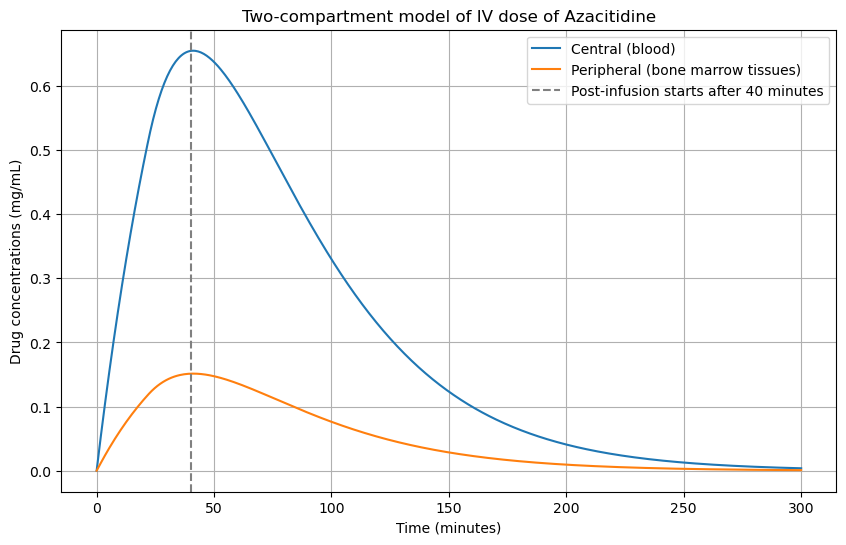

In [5]:
import numpy as np 
from scipy.integrate import odeint
import matplotlib.pyplot as plt 

#initialize the parameters 
k0 = 2.863  #171.35 mL/hr  (rate of infusion)
V1 = 76      #L (total volume of distribution of both compartments, so like blood + tissues) 

k10 = 0.03151 #1.8902 #hr  #0.03151 in minutes   #1/hr (elimination rate)
k12 = 5.34  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers - 
k21 = 23.1   #0.3847 (Q/volume of the intercompartment model)

decay_rate = 0.03151
decay_start = 22 #time when decay begins 

#define the function
def two_compart(y, t):
    C1, C2 = y 

    if t<= decay_start: 
        infusion = k0/V1
    else: 
        time_since_decay = t - decay_start
        infusion = (k0/V1) * np.exp(-decay_rate * time_since_decay) 

    dC1dt = infusion - (k10 + k12)*C1 + k21*C2 #the drug never stops infusing, like eventually it should decrease (post infusion) 
    #dC1dt = (k0/V1) - (k10 + k12)*C1 + k21*C2
    dC2dt = k12*C1 - k21*C2 

    return [dC1dt, dC2dt] 

#initial concentrations 
y0 = [0, 0] 

#time for it to be modelled in
#t_span = (0, 100) 
#t_eval = np.linspace(0, 100, 500) 

t = np.linspace(0, 300, 500) 

#Solve ODE
solution = odeint(two_compart, y0, t) 

C1 = solution[:, 0] 
C2 = solution[:, 1] 

#Plot 
plt.figure(figsize=(10, 6))

plt.plot(t, C1, label = "Central (blood)") 
plt.plot(t, C2, label = "Peripheral (bone marrow tissues)") 

plt.axvline(x=40, color='0.5', linestyle='--', label='Post-infusion starts after 40 minutes')
plt.xlabel("Time (minutes)") 
plt.ylabel("Drug concentrations (mg/mL)") 
plt.grid(True) 
plt.title("Two-compartment model of IV dose of Azacitidine") 
plt.legend()
plt.show() 

# Assistant
The error occurs because the `odeint` function in SciPy expects a different function signature and returns results in a different format than what your code is trying to use.

There are two main issues:
1. The `two_compart` function should take arguments in the order `(y, t)` instead of `(t, y)`
2. The `odeint` function returns an array of solution values, not an object with `y` and `t` attributes

Would you like me to provide the corrected code?

In [8]:
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 

#initialize the parameters 
k0 = 2.863  #171.35 mL/hr 
V1 = 76      #L (total volume of distribution of both compartments, so like blood + tissues) 

k10 = 0.03151 #1.8902 #hr  #0.03151 in minutes   #1/hr
k12 = 5.34  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers
k21 = 23.1   #0.3847

#define the function
def two_compart(t, y):
    C1, C2 = y 

    if t<= 40: 
        #infusion = k0/V1
    else: 
        #infusion = 0 

    dC1dt = infusion - (k10 + k12)*C1 + k21*C2 #the drug never stops infusing, like eventually it should decrease (post infusion) 
    dC1dt = (k0/V1) - (k10 + k12)*C1 + k21*C2
    dC2dt = k12*C1 - k21*C2 

    return [dC1dt, dC2dt] 


#initial concentrations 
y0 = [0, 0] 

#time for it to be modelled in
t_span = (0, 100) 
t_eval = np.linspace(0, 100, 500) 

#Solve ODE
solution = solve_ivp(two_compart, t_span, y0, t_eval=t_eval) 

C1 = solution.y[0] 
C2 = solution.y[1] 

#Plot 
plt.figure(figsize=(10, 6))

plt.plot(solution.t, C1, label = "Central") 
plt.plot(solution.t, C2, label = "Peripheral") 

plt.axvline(x=40, color='0.5', linestyle='--', label='Post-infusion starts after 40 minutes')
plt.xlabel("Time (minutes)") 
plt.ylabel("Drug concentrations (mg/mL)") 
plt.grid(True) 
plt.title("Two-compartment model of IV dose of Azacitidine") 
plt.legend()
plt.show() 

IndentationError: expected an indented block after 'if' statement on line 17 (274056070.py, line 19)